# Wiener Filtering

The Wiener filter is the optimal linear filter for extracting a source signal from a noisy mixture. Given an estimate of the clean source power spectral density (PSD), the filter suppresses frequency bins where the noise dominates and passes bins where the signal dominates:

`W[f] = |source[f]|² / (|source[f]|² + |noise[f]|²)`

This per-bin real gain mask is applied to the mixture STFT. The oracle estimate (using the known clean source) gives the theoretical performance ceiling.

| Function | Description |
| --- | --- |
| `wiener_filter` | Wiener filter: extract a source from a mixture given a spectral estimate of the clean source. Computes the Wiener mask in the STFT domain and returns the filtered signal. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine, generate_white_noise
from python.source_separation import wiener_filter

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Oracle Wiener separation: 440 Hz target sine + 1 kHz interfering sine + 10 % white noise.

**Three panels (time domain + spectra):**
- **Top — mixture spectrum:** all three components visible; 440 Hz target, 1 kHz interferer, and elevated noise floor
- **Middle — Wiener filter output:** the 440 Hz target is largely recovered; the 1 kHz interferer and noise are suppressed in proportion to how much weaker they are relative to the target in each bin
- **Bottom — residual (mixture − filtered):** the suppressed interferer and noise; confirms what the filter removed

**Oracle vs practical Wiener filtering:**
- The oracle mask (used here) uses the *true* clean source magnitude — gives the best possible performance
- In practice, the mask is estimated from noisy observations; imperfect estimates introduce musical noise (isolated residual bins)
- The Wiener filter minimises the mean-square error between the output and the clean source, but does not guarantee perceptual quality



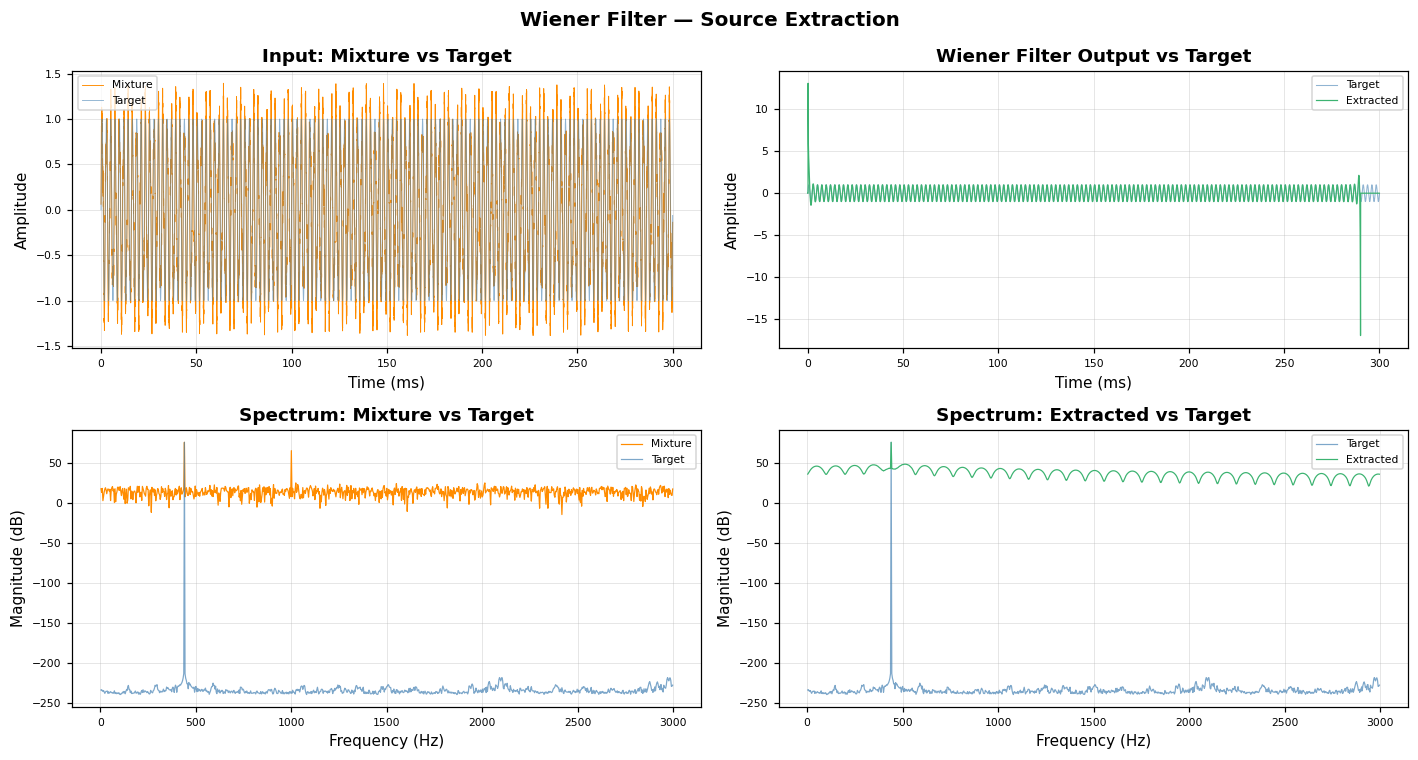

In [2]:
FS = 44100
DURATION = 0.3

_, target = generate_sine(freq=440.0, fs=FS, duration=DURATION)
_, interferer = generate_sine(freq=1000.0, fs=FS, duration=DURATION)
_, noise = generate_white_noise(fs=FS, duration=DURATION, seed=5)

NOISE_LEVEL = 0.3
mixture = target + NOISE_LEVEL * interferer + 0.1 * noise

# Estimate: use the clean target as oracle estimate (best case)
extracted = wiener_filter(mixture, source_estimate=target)

t_ms = np.arange(len(mixture)) / FS * 1000


def _spectrum(s: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    freqs = np.fft.rfftfreq(len(s), d=1.0 / FS)
    db = 20 * np.log10(np.abs(np.fft.rfft(s)) + 1e-12)
    return freqs, db


fig, axes = plt.subplots(2, 2, figsize=(13, 7))

axes[0, 0].plot(t_ms, mixture, linewidth=0.6, color="darkorange", label="Mixture")
axes[0, 0].plot(t_ms, target, linewidth=0.6, color="steelblue", alpha=0.6, label="Target")
axes[0, 0].set_title("Input: Mixture vs Target", fontweight="bold")
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend(fontsize=7)

n = min(len(mixture), len(extracted))
axes[0, 1].plot(t_ms[:n], target[:n], linewidth=0.7, color="steelblue", alpha=0.6, label="Target")
axes[0, 1].plot(t_ms[:n], extracted[:n], linewidth=0.8, color="mediumseagreen", label="Extracted")
axes[0, 1].set_title("Wiener Filter Output vs Target", fontweight="bold")
axes[0, 1].set_xlabel("Time (ms)")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].legend(fontsize=7)

freqs, db_mix = _spectrum(mixture)
freqs, db_tgt = _spectrum(target)
freqs, db_ext = _spectrum(extracted[:n])
mask = (freqs > 0) & (freqs < 3000)
axes[1, 0].plot(freqs[mask], db_mix[mask], linewidth=0.8, color="darkorange", label="Mixture")
axes[1, 0].plot(freqs[mask], db_tgt[mask], linewidth=0.8, color="steelblue", alpha=0.7, label="Target")
axes[1, 0].set_title("Spectrum: Mixture vs Target", fontweight="bold")
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].set_ylabel("Magnitude (dB)")
axes[1, 0].legend(fontsize=7)

axes[1, 1].plot(freqs[mask], db_tgt[mask], linewidth=0.8, color="steelblue", alpha=0.7, label="Target")
axes[1, 1].plot(freqs[mask], db_ext[mask], linewidth=0.8, color="mediumseagreen", label="Extracted")
axes[1, 1].set_title("Spectrum: Extracted vs Target", fontweight="bold")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Magnitude (dB)")
axes[1, 1].legend(fontsize=7)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("Wiener Filter — Source Extraction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

The Wiener filter uses a spectral estimate of the target to suppress interfering signals. Oracle Wiener (clean target as estimate) sets the upper bound.


In [3]:
from IPython.display import Audio, display

DUR_A          = 2.0
_, target_a    = generate_sine(freq=440.0,  fs=FS, duration=DUR_A)
_, interf_a    = generate_sine(freq=1000.0, fs=FS, duration=DUR_A)
_, noise_a     = generate_white_noise(fs=FS, duration=DUR_A, seed=5)

NOISE_LVL_A = 0.3
mixture_a  = target_a + NOISE_LVL_A * interf_a + 0.1 * noise_a
extracted_a = wiener_filter(mixture_a, target_a)

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Noisy mixture — 440 Hz + 1000 Hz interferer + noise")
display(Audio(norm(mixture_a), rate=FS))
print("Clean 440 Hz target (reference)")
display(Audio(norm(target_a), rate=FS))
print("Wiener-filtered output — interferer and noise suppressed")
display(Audio(norm(extracted_a), rate=FS))

Noisy mixture — 440 Hz + 1000 Hz interferer + noise


Clean 440 Hz target (reference)


Wiener-filtered output — interferer and noise suppressed
